# 250 mL Scale-Down -- Transfer-Mass (Mixing) Model, Torispherical Head Geometry, and Serialized Transport Asset

**Scope.** Mass-transfer / mixing physics only -- no reaction kinetics
anywhere in this notebook. The 5 L reference data, model structure, and
fitting logic **mimic `5L_tank_transfer_mass_3_compartments.ipynb` directly**
(re-run against the same experimental CSV, not hand-copied): three
compartments (Zone 1 top/feed+probe, Zone 2 impeller zone, Zone 3 lower dead
zone), adjacent-zone-only transport, `Q_1->2` well-determined / `Q_2->3` only
bounded, `V1_initial != V1_final` tracked explicitly, volumetric titrant flow
rate reported at both scales.

**What's new in this revision:**
1. **250 mL geometry is now exact** (measured), not a placeholder:
   `D_tank=7.085 cm`, `D_impeller=5 cm`, `H_impeller=1.123 cm`,
   `H_liquid_initial=7.870 cm`, unbaffled.
2. **Torispherical bottom-head model** for the 250 mL vessel's dished base,
   replacing the flat-cylinder assumption -- crown radius `R`, knuckle radius
   `a`, and exact head volume computed for both the ASME (F&D, 6% knuckle) and
   DIN 28011 (Klopper, 10% knuckle) standards, given `D=7.085 cm` and head
   depth `h=1.123 cm`.
3. **A genuine structural finding falls out of the given numbers**: the
   impeller's nominal swept zone (`h_impeller +/- D_impeller/2`) would extend
   to `z = 1.123 - 2.5 = -1.377 cm` -- *below* the physical vessel base. That
   means the impeller's zone of influence fully engulfs the torispherical
   head; there is no separate quiescent Zone 3 at this scale. The 250 mL
   vessel is therefore modeled as a **2-compartment** system (Zone 1 top,
   Zone 2 = head + impeller swept cylinder merged), while the 5 L reference
   keeps its validated 3-compartment treatment unchanged.
4. All computed geometry, zone volumes, `Q`/`Nq` transport parameters, and
   scale-down criteria are bundled into a `ReactorGeometryModel` object and
   serialized with `dill` to `reactor_geometry_transport.dill`, then reloaded
   in-notebook to confirm the round trip works.

**5 L parent reactor geometry is read/preserved exactly as previously
defined** (Sections 1-4 below, unchanged) -- only the 250 mL vessel and
everything derived from it is updated in this revision.

**No Git staging, committing, or pushing operations are performed by this
notebook or by building it.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import dill
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares, brentq
from scipy.stats import chi2

## Section 1 -- 5 L reference vessel geometry & 3-zone split (mimics `5L_tank_transfer_mass_3_compartments.ipynb` Cell 1)

Same vessel/impeller/probe geometry, same 160 rpm titration run, same
zone-boundary rule (Zone 2 = one impeller diameter tall, centered on the
impeller -- a structural choice, not fit from data; the two *fit* parameters
are the flow rates, not this boundary). **Preserved unchanged from the prior
revision.**

In [2]:
# --- vessel & liquid geometry (identical to 5L_tank_transfer_mass_3_compartments.ipynb Cell 1) ---
D_IMPELLER_5L_CM = 7.5
D_TANK_5L_CM = 20.5
H_IMPELLER_5L_CM = 8.0            # impeller clearance from tank bottom
H_LIQUID_INITIAL_5L_CM = 17.2     # liquid height BEFORE the titrant feed
A_CROSS_5L_CM2 = np.pi * (D_TANK_5L_CM / 2) ** 2

N_RPM_5L = 160.0                  # this reference run's condition
N_RPS_5L = N_RPM_5L / 60.0

PH_PROBE_HEIGHT_5L_CM = 12.6

# --- HCl titrant feed (continuous, not a pulse) ---
V_HCL_TOTAL_5L_ML = 266.0
PUMP_RATE_5L_ML_MIN = 110.0       # <-- volumetric flow rate of the pH titrant, 5 L scale
T_FEED_END_5L_MIN = V_HCL_TOTAL_5L_ML / PUMP_RATE_5L_ML_MIN
PUMP_RATE_5L_L_MIN = PUMP_RATE_5L_ML_MIN / 1000.0

# --- chemistry ---
C_TRIS_STOCK_M = 0.20000
C_HCL_STOCK_M = 1.0
PKA_TRIS = 8.06

print(f"Volumetric titrant flow rate (5 L): {PUMP_RATE_5L_ML_MIN:.1f} mL/min ({PUMP_RATE_5L_L_MIN:.4f} L/min)")
print(f"Titrant feed duration (5 L)       : {T_FEED_END_5L_MIN:.4f} min ({T_FEED_END_5L_MIN*60:.2f} s)")

# --- 3-zone axial split ---
def zone_boundaries(h_impeller_cm, D_impeller_cm):
    z_lower = h_impeller_cm - D_impeller_cm / 2.0
    z_upper = h_impeller_cm + D_impeller_cm / 2.0
    return z_lower, z_upper

def zone_volumes_L(A_cross_cm2, z_lower_cm, z_upper_cm, h_liquid_initial_cm, V_titrant_total_mL):
    '''Returns (V3_fixed, V2_fixed, V1_initial, V1_final, V_total_initial, V_total_final), all in L.
    V1 (top zone) grows from V1_initial to V1_final as the titrant is added -- starting volume
    is NOT the final volume, tracked explicitly throughout this notebook.'''
    V3 = (A_cross_cm2 * z_lower_cm) / 1000.0
    V2 = (A_cross_cm2 * (z_upper_cm - z_lower_cm)) / 1000.0
    V1_initial = (A_cross_cm2 * (h_liquid_initial_cm - z_upper_cm)) / 1000.0
    V1_final = V1_initial + V_titrant_total_mL / 1000.0
    V_total_initial = V3 + V2 + V1_initial
    V_total_final = V3 + V2 + V1_final
    return V3, V2, V1_initial, V1_final, V_total_initial, V_total_final

z2_lower_5L, z2_upper_5L = zone_boundaries(H_IMPELLER_5L_CM, D_IMPELLER_5L_CM)
V3_5L, V2_5L, V1_initial_5L, V1_final_5L, V_total_initial_5L, V_total_final_5L = zone_volumes_L(
    A_CROSS_5L_CM2, z2_lower_5L, z2_upper_5L, H_LIQUID_INITIAL_5L_CM, V_HCL_TOTAL_5L_ML)

print(f"\nZone 3 (lower bulk)      : 0.00 - {z2_lower_5L:.2f} cm  ->  V3 = {V3_5L:.3f} L (fixed)")
print(f"Zone 2 (impeller zone)   : {z2_lower_5L:.2f} - {z2_upper_5L:.2f} cm  ->  V2 = {V2_5L:.3f} L (fixed)")
print(f"Zone 1 (top, feed+probe) : {z2_upper_5L:.2f} - {H_LIQUID_INITIAL_5L_CM:.2f} cm (initial)")
print(f"  V1_initial (BEFORE titrant feed) = {V1_initial_5L:.3f} L")
print(f"  V1_final   (AFTER titrant feed)  = {V1_final_5L:.3f} L   <-- starting != final volume")
print(f"V_total_initial = {V_total_initial_5L:.3f} L   |   V_total_final = {V_total_final_5L:.3f} L")
print(f"N (rotation speed) = {N_RPS_5L:.4f} rev/s ({N_RPM_5L:.0f} RPM)")

Volumetric titrant flow rate (5 L): 110.0 mL/min (0.1100 L/min)
Titrant feed duration (5 L)       : 2.4182 min (145.09 s)

Zone 3 (lower bulk)      : 0.00 - 4.25 cm  ->  V3 = 1.403 L (fixed)
Zone 2 (impeller zone)   : 4.25 - 11.75 cm  ->  V2 = 2.475 L (fixed)
Zone 1 (top, feed+probe) : 11.75 - 17.20 cm (initial)
  V1_initial (BEFORE titrant feed) = 1.799 L
  V1_final   (AFTER titrant feed)  = 2.065 L   <-- starting != final volume
V_total_initial = 5.677 L   |   V_total_final = 5.943 L
N (rotation speed) = 2.6667 rev/s (160 RPM)


## Section 2 -- 3-compartment forward model + joint fit of `Q_1->2`, `Q_2->3` (re-run against the real 5 L CSV)

Identical model and fitting method to `5L_tank_transfer_mass_3_compartments.ipynb`:
`Q_1->2` (fast, impeller-driven, Zone1<->Zone2) and `Q_2->3` (slow,
Zone2<->Zone3) fit jointly via `least_squares` against the measured `pH(t)`.
**Preserved unchanged.**

In [3]:
def V1_of_t(t_min, V1_initial_L, feed_L_min, t_feed_end_min):
    added = feed_L_min * min(t_min, t_feed_end_min)
    return V1_initial_L + added

def feed_rate_mol_min(t_min, feed_L_min, t_feed_end_min, C_HCl_M):
    if t_min <= t_feed_end_min:
        return feed_L_min * C_HCl_M
    return 0.0

def simulate_ph_3zone(Q12_L_min, Q23_L_min, t_eval_min, pH0,
                       V1_initial_L, V2_L, V3_L, feed_L_min, t_feed_end_min,
                       C_Tris_M=C_TRIS_STOCK_M, C_HCl_M=C_HCL_STOCK_M, pKa=PKA_TRIS):
    '''Simulate Zone-1 (probe) pH(t) for given inter-zone flows. pH0 sets the initial
    protonation fraction, applied uniformly across all 3 zones, via inverse Henderson-Hasselbalch.'''
    ratio0 = 10 ** (pH0 - pKa)
    frac_TrisH_0 = 1.0 / (1.0 + ratio0)

    n_Tris_1_0 = (1 - frac_TrisH_0) * C_Tris_M * V1_initial_L
    n_TrisH_1_0 = frac_TrisH_0 * C_Tris_M * V1_initial_L
    n_Tris_2_0 = (1 - frac_TrisH_0) * C_Tris_M * V2_L
    n_TrisH_2_0 = frac_TrisH_0 * C_Tris_M * V2_L
    n_Tris_3_0 = (1 - frac_TrisH_0) * C_Tris_M * V3_L
    n_TrisH_3_0 = frac_TrisH_0 * C_Tris_M * V3_L
    y0 = [n_Tris_1_0, n_TrisH_1_0, n_Tris_2_0, n_TrisH_2_0, n_Tris_3_0, n_TrisH_3_0]

    def ode(t_min, y):
        n_Tris_1, n_TrisH_1, n_Tris_2, n_TrisH_2, n_Tris_3, n_TrisH_3 = np.maximum(y, 0.0)
        V1 = V1_of_t(t_min, V1_initial_L, feed_L_min, t_feed_end_min)
        C_Tris_1, C_TrisH_1 = n_Tris_1 / V1, n_TrisH_1 / V1
        C_Tris_2, C_TrisH_2 = n_Tris_2 / V2_L, n_TrisH_2 / V2_L
        C_Tris_3, C_TrisH_3 = n_Tris_3 / V3_L, n_TrisH_3 / V3_L

        exch12_Tris = Q12_L_min * (C_Tris_1 - C_Tris_2)
        exch12_TrisH = Q12_L_min * (C_TrisH_1 - C_TrisH_2)
        exch23_Tris = Q23_L_min * (C_Tris_2 - C_Tris_3)
        exch23_TrisH = Q23_L_min * (C_TrisH_2 - C_TrisH_3)
        h_feed = feed_rate_mol_min(t_min, feed_L_min, t_feed_end_min, C_HCl_M)

        return [-exch12_Tris - h_feed, -exch12_TrisH + h_feed,
                +exch12_Tris - exch23_Tris, +exch12_TrisH - exch23_TrisH,
                +exch23_Tris, +exch23_TrisH]

    t_end = t_eval_min[-1]
    if t_end <= t_feed_end_min:
        sol = solve_ivp(ode, (0, t_end), y0, t_eval=t_eval_min, method='BDF', rtol=1e-7, atol=1e-10)
        Y = sol.y
    else:
        mask1 = t_eval_min <= t_feed_end_min
        t1 = np.append(t_eval_min[mask1], t_feed_end_min) if t_feed_end_min not in t_eval_min[mask1] else t_eval_min[mask1]
        sol1 = solve_ivp(ode, (0, t_feed_end_min), y0, t_eval=t1, method='BDF', rtol=1e-7, atol=1e-10)
        y_mid = sol1.y[:, -1]
        t2 = t_eval_min[~mask1]
        sol2 = solve_ivp(ode, (t_feed_end_min, t_end), y_mid, t_eval=t2, method='BDF', rtol=1e-7, atol=1e-10)
        Y = np.hstack([sol1.y[:, :len(t_eval_min[mask1])], sol2.y])

    n_Tris_1, n_TrisH_1 = Y[0], Y[1]
    V1_series = np.array([V1_of_t(tm, V1_initial_L, feed_L_min, t_feed_end_min) for tm in t_eval_min])
    C_Tris_1 = np.maximum(n_Tris_1, 1e-12) / V1_series
    C_TrisH_1 = np.maximum(n_TrisH_1, 1e-12) / V1_series
    return pKa + np.log10(C_Tris_1 / C_TrisH_1)


def fit_3zone_transport(csv_path, V1_initial_L, V2_L, V3_L, feed_L_min, t_feed_end_min,
                         D_impeller_m, N_rps, Nq_max_literature=1.0,
                         Q12_0=None, Q23_0=None, robustness_seeds=(0.5, 5.0, 50.0, 500.0, 5000.0)):
    '''Generic joint fit of (Q12, Q23) to a measured (t_sec, pH) CSV -- same method as
    5L_tank_transfer_mass_3_compartments.ipynb: joint least_squares, Jacobian rank check,
    profile-likelihood stderr for Q12, multi-seed robustness + 95% lower bound for Q23,
    and a physically-motivated ceiling refit (Q23 cannot exceed Nq_max_literature).'''
    df_exp = pd.read_csv(csv_path, usecols=[0, 1])
    df_exp.columns = ['t_sec', 'pH']
    t_seconds = df_exp['t_sec'].to_numpy(dtype=float)
    pH_measured = df_exp['pH'].to_numpy(dtype=float)

    V_total_L = V1_initial_L + V2_L + V3_L
    if Q12_0 is None:
        Q12_0 = V_total_L * 3.0
    if Q23_0 is None:
        Q23_0 = V_total_L * 0.05

    def residuals(params, t_sec_arr, pH_arr):
        Q12, Q23 = params
        pH_sim = simulate_ph_3zone(Q12, Q23, t_sec_arr / 60.0, pH_arr[0],
                                    V1_initial_L, V2_L, V3_L, feed_L_min, t_feed_end_min)
        return pH_sim - pH_arr

    fit_result = least_squares(residuals, x0=[Q12_0, Q23_0], args=(t_seconds, pH_measured),
                                bounds=([1e-3, 1e-4], [1e4, 1e4]), method='trf', xtol=1e-12, ftol=1e-12)
    Q12_fit, Q23_fit = fit_result.x

    J = fit_result.jac
    _, S_svd, _ = np.linalg.svd(J, full_matrices=False)
    cond_number = S_svd[0] / S_svd[-1]

    def resid_Q12_only(p):
        return residuals([p[0], Q23_fit], t_seconds, pH_measured)
    prof_Q12 = least_squares(resid_Q12_only, x0=[Q12_fit], bounds=([1e-3], [1e4]), xtol=1e-13, ftol=1e-13)
    J_prof = prof_Q12.jac
    var_Q12 = (2 * prof_Q12.cost / max(1, len(prof_Q12.fun) - 1)) / (J_prof[:, 0] @ J_prof[:, 0])
    Q12_stderr = np.sqrt(var_Q12)

    n_pts, n_params = len(pH_measured), 2
    sigma2 = 2.0 * fit_result.cost / (n_pts - n_params)
    cost_threshold_95 = fit_result.cost + 0.5 * chi2.ppf(0.95, df=1) * sigma2

    def profile_cost_Q23(Q23_fixed):
        def resid_at_fixed_Q23(p):
            return residuals([p[0], Q23_fixed], t_seconds, pH_measured)
        rp = least_squares(resid_at_fixed_Q23, x0=[Q12_fit], bounds=([1e-3], [1e3]), xtol=1e-13, ftol=1e-13)
        return rp.cost - cost_threshold_95

    Q23_lower_95 = brentq(profile_cost_Q23, 1.0, Q23_fit, xtol=0.01)

    multistart_Q12, multistart_Q23 = [], []
    for seed in robustness_seeds:
        r = least_squares(residuals, x0=[Q12_0, seed], args=(t_seconds, pH_measured),
                           bounds=([1e-3, 1e-4], [1e4, 1e4]), method='trf', xtol=1e-12, ftol=1e-12)
        multistart_Q12.append(r.x[0])
        multistart_Q23.append(r.x[1])

    Q_physical_ceiling = Nq_max_literature * N_rps * D_impeller_m ** 3 * 1000.0 * 60.0
    fit_c = least_squares(residuals, x0=[Q12_0, Q23_0], args=(t_seconds, pH_measured),
                           bounds=([1e-3, 1e-4], [1e4, Q_physical_ceiling]), method='trf', xtol=1e-12, ftol=1e-12)
    Q12_fit_c, Q23_fit_c = fit_c.x

    Nq_12 = (Q12_fit / 1000.0 / 60.0) / (N_rps * D_impeller_m ** 3)
    Nq_23_lower = (Q23_lower_95 / 1000.0 / 60.0) / (N_rps * D_impeller_m ** 3)

    return dict(t_seconds=t_seconds, pH_measured=pH_measured,
                Q12_fit=Q12_fit, Q12_stderr=Q12_stderr, Q23_fit_unconstrained=Q23_fit,
                Q23_lower_95=Q23_lower_95, Q_physical_ceiling=Q_physical_ceiling,
                Q12_fit_c=Q12_fit_c, Q23_fit_c=Q23_fit_c,
                Nq_12=Nq_12, Nq_23_lower=Nq_23_lower, Nq_max_literature=Nq_max_literature,
                cond_number=cond_number, cost=fit_result.cost,
                rmse=np.sqrt(np.mean(fit_result.fun ** 2)),
                multistart_Q12_range=(min(multistart_Q12), max(multistart_Q12)),
                multistart_Q23_range=(min(multistart_Q23), max(multistart_Q23)))


D_IMPELLER_5L_M = D_IMPELLER_5L_CM / 100.0
CSV_5L_PATH = 'pH adjustment Exp - Exp2_09072026.csv'
fit_5L = fit_3zone_transport(CSV_5L_PATH, V1_initial_5L, V2_5L, V3_5L,
                              PUMP_RATE_5L_L_MIN, T_FEED_END_5L_MIN,
                              D_IMPELLER_5L_M, N_RPS_5L)

print("=" * 74)
print("  5 L REFERENCE -- 3-COMPARTMENT FIT (160 RPM titration run)")
print("=" * 74)
print(f"  Jacobian condition number : {fit_5L['cond_number']:.3e} "
      f"({'RANK-DEFICIENT' if fit_5L['cond_number'] > 1e6 else 'well-conditioned'})")
print(f"  Q_1->2 (well-determined)  : {fit_5L['Q12_fit']:.4f} +/- {fit_5L['Q12_stderr']:.4f} L/min")
print(f"    multi-seed range        : {fit_5L['multistart_Q12_range'][0]:.3f} - {fit_5L['multistart_Q12_range'][1]:.3f} L/min (reproducible)")
print(f"  Q_2->3 (NOT point-identifiable):")
print(f"    95% CI lower bound      : {fit_5L['Q23_lower_95']:.2f} L/min")
print(f"    physical ceiling (Nq<={fit_5L['Nq_max_literature']}) : {fit_5L['Q_physical_ceiling']:.2f} L/min")
print(f"    multi-seed range        : {fit_5L['multistart_Q23_range'][0]:.0f} - {fit_5L['multistart_Q23_range'][1]:.0f} L/min (NOT reproducible -- confirms non-identifiability)")
print(f"  Nq (from Q_1->2)          : {fit_5L['Nq_12']:.4f}")
print(f"  Nq (from Q_2->3's 95% lower bound; no upper Nq exists): > {fit_5L['Nq_23_lower']:.4f}")
print(f"  RMSE                      : {fit_5L['rmse']:.5f} pH units")

  5 L REFERENCE -- 3-COMPARTMENT FIT (160 RPM titration run)
  Jacobian condition number : 1.489e+08 (RANK-DEFICIENT)
  Q_1->2 (well-determined)  : 8.3538 +/- 0.4216 L/min
    multi-seed range        : 8.352 - 8.355 L/min (reproducible)
  Q_2->3 (NOT point-identifiable):
    95% CI lower bound      : 10.75 L/min
    physical ceiling (Nq<=1.0) : 67.50 L/min
    multi-seed range        : 2015 - 4765 L/min (NOT reproducible -- confirms non-identifiability)
  Nq (from Q_1->2)          : 0.1238
  Nq (from Q_2->3's 95% lower bound; no upper Nq exists): > 0.1593
  RMSE                      : 0.06496 pH units


## Section 3 -- Transport-matrix eigenvalue timescales (fast/slow), 5 L reference

Same diagnostic as the reference notebook's Cell 3e: the two non-zero
eigenvalues of the post-feed-end linear transport matrix give the fast
(Zone1<->Zone2) and slow (Zone2<->Zone3) relaxation timescales directly from
`Q_1->2`, `Q_2->3`, and the (now-fixed, post-feed) volumes -- not fit to data.
**Preserved unchanged.**

In [4]:
def transport_eigs_per_min(V1_post_feed_L, V2_L, V3_L, Q12, Q23):
    '''Returns (slow_rate, fast_rate), both positive, per minute.'''
    Am = np.array([
        [-Q12 / V1_post_feed_L,  Q12 / V2_L,                        0],
        [ Q12 / V1_post_feed_L, -(Q12 / V2_L + Q23 / V2_L),  Q23 / V3_L],
        [0,                      Q23 / V2_L,                -Q23 / V3_L],
    ])
    eigs = np.sort(np.linalg.eigvals(Am).real)
    return -eigs[1], -eigs[0]   # (slow_rate, fast_rate), per minute

slow_5L, fast_5L = transport_eigs_per_min(V1_final_5L, V2_5L, V3_5L, fit_5L['Q12_fit'], fit_5L['Q_physical_ceiling'])
print(f"5 L reference timescales (Q_2->3 at physical ceiling, the best available single-number proxy):")
print(f"  fast tau (Zone1<->Zone2) = {1/fast_5L*60:.2f} s")
print(f"  slow tau (Zone2<->Zone3) = {1/slow_5L*60:.2f} s")

5 L reference timescales (Q_2->3 at physical ceiling, the best available single-number proxy):
  fast tau (Zone1<->Zone2) = 0.78 s
  slow tau (Zone2<->Zone3) = 9.85 s


## Section 4 -- 5 L summary: Nq and Q at both flow scales (impeller-driven vs. secondary)

Explicit answer to "provide Nq and Q values" for the 5 L reference, before
scaling down. **Preserved unchanged.**

In [5]:
Q23_lower_str = '>' + format(fit_5L['Q23_lower_95'], '.2f')
Nq23_lower_str = '>' + format(fit_5L['Nq_23_lower'], '.4f')

print(f"{'Flow':<10}{'Q (L/min)':>16}{'Nq':>12}{'Status':>28}")
print('-' * 66)
print(f"{'Q_1->2':<10}{fit_5L['Q12_fit']:>16.4f}{fit_5L['Nq_12']:>12.4f}{'point value, well-determined':>28}")
print(f"{'Q_2->3':<10}{Q23_lower_str:>16}{Nq23_lower_str:>12}{'lower bound only':>28}")
print(f"{'Q_2->3':<10}{fit_5L['Q_physical_ceiling']:>16.2f}{fit_5L['Nq_max_literature']:>12.4f}{'physical ceiling (not a fit)':>28}")

Flow             Q (L/min)          Nq                      Status
------------------------------------------------------------------
Q_1->2              8.3538      0.1238point value, well-determined
Q_2->3              >10.75     >0.1593            lower bound only
Q_2->3               67.50      1.0000physical ceiling (not a fit)


## Section 4b -- 5 L mixing time (theta_95)

Added metric (Phase 4 asks for `theta_95` at "both scale conditions"). For a
linear system, the slowest eigenmode dominates the long-time approach to
homogeneity: `theta_95 = ln(20) / slow_rate` (time to close to within 5% of
the fully-mixed state).

In [6]:
theta95_5L_min = np.log(20.0) / slow_5L
print(f"5 L reference theta_95 (95% mixing time, Q_2->3 at physical ceiling) = {theta95_5L_min:.3f} min "
      f"({theta95_5L_min*60:.1f} s)")

5 L reference theta_95 (95% mixing time, Q_2->3 at physical ceiling) = 0.492 min (29.5 s)


## Section 5 -- 250 mL vessel geometry **(EXACT -- measured, no longer a placeholder)**

Updated per the confirmed specification. `NQ_MAX_LITERATURE_250` is set to
the same literature-anchored ceiling used for the 5 L reference's `Q_2->3`
characterization (`Nq<=1.0`).

**2026-07-20 -- investigation log:** a `Nq<=2.5` exploratory relaxation was
tried and reverted -- widening the ceiling did not settle to an interior
optimum (the fit just re-pinned at the new edge with a shrinking cost gap),
confirming the mismatch is not a mixing-rate identifiability problem. Back
to the literature-anchored `Nq<=1.0` ceiling while the actual cause is
chased down via Section 12's mass-balance cross-check: `C_HCL_STOCK_M` and
the HCl delivery (13.75 mL delivered within 145 s) have since been
**confirmed correct**; `C_TRIS_STOCK_M` is under active investigation.

In [7]:
# =====================================================================
# 250 mL VESSEL GEOMETRY -- CONFIRMED / MEASURED (no longer a placeholder)
# =====================================================================
GEOMETRY_IS_PLACEHOLDER = False    # confirmed measured values below

D_TANK_250_CM           = 7.085
D_IMPELLER_250_CM       = 5.0
H_IMPELLER_250_CM       = 1.123     # impeller clearance from tank bottom
H_LIQUID_INITIAL_250_CM = 7.870     # liquid height BEFORE titrant feed
BAFFLED_250             = False
NQ_MAX_LITERATURE_250   = 1.0     # literature-anchored ceiling (2026-07-20: 2.5 exploratory relaxation reverted, see Section 5 markdown)

D_IMPELLER_250_M = D_IMPELLER_250_CM / 100.0
A_CROSS_250_CM2 = np.pi * (D_TANK_250_CM / 2) ** 2

print(f"250 mL geometry (confirmed measured values):")
print(f"  D_tank           = {D_TANK_250_CM:.3f} cm")
print(f"  D_impeller       = {D_IMPELLER_250_CM:.3f} cm")
print(f"  H_impeller       = {H_IMPELLER_250_CM:.3f} cm (clearance from tank bottom)")
print(f"  H_liquid_initial = {H_LIQUID_INITIAL_250_CM:.3f} cm (before titrant feed)")
print(f"  Baffled          = {BAFFLED_250}")
print(f"  A_cross          = {A_CROSS_250_CM2:.3f} cm^2")
print(f"  Impeller/tank diameter ratio = {D_IMPELLER_250_CM/D_TANK_250_CM:.3f} "
      f"(5 L reference ratio: {D_IMPELLER_5L_CM/D_TANK_5L_CM:.3f} -- this vessel's impeller is proportionally much larger)")

250 mL geometry (confirmed measured values):
  D_tank           = 7.085 cm
  D_impeller       = 5.000 cm
  H_impeller       = 1.123 cm (clearance from tank bottom)
  H_liquid_initial = 7.870 cm (before titrant feed)
  Baffled          = False
  A_cross          = 39.425 cm^2
  Impeller/tank diameter ratio = 0.706 (5 L reference ratio: 0.366 -- this vessel's impeller is proportionally much larger)


## Section 6 -- Phase 1: Torispherical head geometry refinement

Exact torispherical (dished) head volume, following the standard closed-form
solution (crown radius `R`, knuckle radius `a`, `c = D/2 - a`):

$$V_{head} = \frac{\pi}{3}\Big[2hR^2-(2a^2+c^2+2aR)(R-h)+3a^2c\,\sin^{-1}\frac{R-h}{R-a}\Big]$$

with the head-depth constraint `h = R - sqrt((R-a)^2 - (D/2-a)^2)` relating
`R`, `a`, `D`, and `h`. Given the **measured** `D=7.085 cm` and
`h=1.123 cm` (the impeller-baseline/knuckle coordinate boundary), `R` is
solved for under each standard's fixed knuckle ratio:

- **ASME** (Flanged & Dished, "6% knuckle"): `R = D`, `a = 0.06D` (as a
  *starting* ratio -- `R` here is *solved*, not assumed, from the given `h`).
- **DIN 28011** (Klopper): `a = 0.10D`.

Reference: [Torispherical Head Volume and Weight Calculation
(Kezar Engineering)](https://kezareng.com/articles/torispherical-head-volume-and-weight).

In [8]:
def solve_R_from_D_h_a(D_cm, h_cm, a_cm):
    '''Solve for crown radius R given D, target head depth h, and knuckle radius a,
    from h = R - sqrt((R-a)^2 - (D/2-a)^2). Returns (R, c) with c = D/2 - a.'''
    c = D_cm / 2.0 - a_cm
    numerator = a_cm ** 2 - h_cm ** 2 - c ** 2
    denominator = 2.0 * (a_cm - h_cm)
    R = numerator / denominator
    return R, c

def torispherical_head_volume_cm3(R_cm, a_cm, c_cm, h_cm):
    '''Exact internal volume (cm^3 = mL) of a torispherical head, apex to tangent line.'''
    term1 = 2.0 * h_cm * R_cm ** 2
    term2 = (2.0 * a_cm ** 2 + c_cm ** 2 + 2.0 * a_cm * R_cm) * (R_cm - h_cm)
    term3 = 3.0 * a_cm ** 2 * c_cm * np.arcsin((R_cm - h_cm) / (R_cm - a_cm))
    return (np.pi / 3.0) * (term1 - term2 + term3)

def head_depth_from_R_a(R_cm, a_cm, D_cm):
    '''Inverse check: given R, a, D, what head depth h does that imply?'''
    c = D_cm / 2.0 - a_cm
    return R_cm - np.sqrt((R_cm - a_cm) ** 2 - c ** 2)

TORISPHERICAL_STANDARDS = {'ASME': 0.06, 'DIN': 0.10}   # knuckle radius as fraction of D

def torispherical_report(D_cm, h_cm, standards=TORISPHERICAL_STANDARDS):
    rows = {}
    for name, a_ratio in standards.items():
        a = a_ratio * D_cm
        R, c = solve_R_from_D_h_a(D_cm, h_cm, a)
        V_head = torispherical_head_volume_cm3(R, a, c, h_cm)
        h_check = head_depth_from_R_a(R, a, D_cm)
        rows[name] = dict(a=a, R=R, c=c, h=h_cm, V_head_mL=V_head, h_check=h_check)
    return rows

torispherical_250 = torispherical_report(D_TANK_250_CM, H_IMPELLER_250_CM)

print("=" * 82)
print("  250 mL BOTTOM HEAD -- TORISPHERICAL GEOMETRY, ASME vs DIN")
print(f"  (D = {D_TANK_250_CM} cm, h = {H_IMPELLER_250_CM} cm)")
print("=" * 82)
print(f"{'Standard':<10}{'a (cm)':>10}{'R (cm)':>10}{'c (cm)':>10}{'V_head (mL)':>14}{'h check':>10}")
print('-' * 64)
for name, row in torispherical_250.items():
    print(f"{name:<10}{row['a']:>10.4f}{row['R']:>10.4f}{row['c']:>10.4f}{row['V_head_mL']:>14.4f}{row['h_check']:>10.6f}")

TORISPHERICAL_STANDARD_250 = 'ASME'   # selected operating standard for downstream compartment volumes
V_head_250_selected = torispherical_250[TORISPHERICAL_STANDARD_250]['V_head_mL']
print(f"\nSelected standard for downstream use: {TORISPHERICAL_STANDARD_250} "
      f"(V_head = {V_head_250_selected:.4f} mL)")

# --- contrast against the 5 L reference's existing (flat-cylinder) Zone-3 model ---
# 5 L geometry/Zone-3 boundary are PRESERVED unchanged above; this is an informational
# comparison only -- it does NOT alter V3_5L used elsewhere in this notebook.
torispherical_5L_contrast = torispherical_report(D_TANK_5L_CM, z2_lower_5L)
print(f"\nContrast vs. 5 L reference's existing flat-bottom Zone-3 model "
      f"(D={D_TANK_5L_CM} cm, h=z2_lower={z2_lower_5L:.2f} cm; 5 L geometry itself is unchanged):")
print(f"  Current flat-cylinder Zone 3 volume : {V3_5L*1000:.2f} mL")
for name, row in torispherical_5L_contrast.items():
    delta = row['V_head_mL'] - V3_5L * 1000.0
    print(f"  {name} torispherical equivalent      : {row['V_head_mL']:.2f} mL "
          f"(delta = {delta:+.2f} mL, {delta/(V3_5L*1000.0)*100:+.1f}%)")

  250 mL BOTTOM HEAD -- TORISPHERICAL GEOMETRY, ASME vs DIN
  (D = 7.085 cm, h = 1.123 cm)
Standard      a (cm)    R (cm)    c (cm)   V_head (mL)   h check
----------------------------------------------------------------
ASME          0.4251    7.7365    3.1174       27.4144  1.123000
DIN           0.7085   10.6040    2.8340       31.3001  1.123000

Selected standard for downstream use: ASME (V_head = 27.4144 mL)

Contrast vs. 5 L reference's existing flat-bottom Zone-3 model (D=20.5 cm, h=z2_lower=4.25 cm; 5 L geometry itself is unchanged):
  Current flat-cylinder Zone 3 volume : 1402.77 mL
  ASME torispherical equivalent      : 822.26 mL (delta = -580.51 mL, -41.4%)
  DIN torispherical equivalent      : 891.59 mL (delta = -511.18 mL, -36.4%)


## Section 7 -- Phase 2: Compartment discretization for 250 mL, using the updated head profile

Applying the *same* zone-boundary rule as the 5 L reference (impeller zone =
one impeller diameter tall, centered on the impeller) to the 250 mL geometry
produces a **negative** lower boundary:

`z2_lower = H_impeller - D_impeller/2 = 1.123 - 2.5 = -1.377 cm`

This is not a numerical error -- it is a real consequence of this vessel's
unusually large impeller-to-tank diameter ratio (0.706 vs. 0.366 at 5 L). It
means the impeller's nominal swept envelope extends *below the physical
vessel base*, i.e. **the impeller's zone of influence fully engulfs the
torispherical head**. There is no separate quiescent Zone 3 at this scale.

**Consequence:** the 250 mL vessel is dynamically mapped to a **2-compartment**
system: Zone 2 becomes "head + impeller-swept cylinder" (volume = exact
torispherical head volume + the remaining straight-cylinder portion up to
`z2_upper`), and Zone 3 is dropped (volume 0). Zone 1 (top) is unchanged in
form. This is analogous in spirit to the reference notebook's own finding
that `Q_2->3` isn't a well-posed point value -- here the compartment
structure itself, not just one flow rate, degenerates at this scale.

In [9]:
z2_lower_naive_250 = H_IMPELLER_250_CM - D_IMPELLER_250_CM / 2.0
z2_upper_250 = H_IMPELLER_250_CM + D_IMPELLER_250_CM / 2.0

print(f"z2_lower (naive, symmetric-swept-zone rule) = {z2_lower_naive_250:.4f} cm")
print(f"z2_upper                                    = {z2_upper_250:.4f} cm")

ZONE3_DEGENERATE_250 = z2_lower_naive_250 <= 0.0

if ZONE3_DEGENERATE_250:
    print("\n-> DEGENERATE: z2_lower < 0 -- impeller swept zone engulfs the entire torispherical head.")
    print("   Zone 3 has zero volume; 250 mL is modeled as a 2-compartment system (Zone 1 / Zone 2).")
    V3_250 = 0.0
    V2_250 = V_head_250_selected + A_CROSS_250_CM2 * (z2_upper_250 - H_IMPELLER_250_CM)
    z2_lower_250_effective = 0.0
else:
    # Not triggered by this vessel's given numbers; retained for completeness/generality.
    # Would require a partial (0 -> z2_lower) torispherical integral for full precision --
    # flagged here as a documented limitation rather than silently approximated.
    print("\n-> z2_lower >= 0: classical 3-zone split applies; using flat-cylinder Zone 3 "
          "(a partial torispherical integral would be more precise but is not needed here).")
    V3_250 = A_CROSS_250_CM2 * z2_lower_naive_250 / 1000.0
    V2_250 = A_CROSS_250_CM2 * (z2_upper_250 - z2_lower_naive_250) / 1000.0
    z2_lower_250_effective = z2_lower_naive_250

if ZONE3_DEGENERATE_250:
    V2_250 = V2_250 / 1000.0   # cm^3 (mL) -> L

V1_initial_250 = A_CROSS_250_CM2 * (H_LIQUID_INITIAL_250_CM - z2_upper_250) / 1000.0
V_total_initial_250 = V3_250 + V2_250 + V1_initial_250

print(f"\nZone 3 (dead zone)       : volume = {V3_250*1000:.4f} mL (degenerate -> 0)" if ZONE3_DEGENERATE_250
      else f"\nZone 3 (dead zone)       : 0.00 - {z2_lower_250_effective:.2f} cm -> V3 = {V3_250*1000:.4f} mL")
print(f"Zone 2 (impeller + head) : {z2_lower_250_effective:.2f} - {z2_upper_250:.2f} cm "
      f"(curved head {H_IMPELLER_250_CM:.3f} cm + straight cylinder {z2_upper_250-H_IMPELLER_250_CM:.3f} cm) "
      f"-> V2 = {V2_250*1000:.4f} mL")
print(f"Zone 1 (top, feed+probe) : {z2_upper_250:.2f} - {H_LIQUID_INITIAL_250_CM:.2f} cm (initial) "
      f"-> V1_initial = {V1_initial_250*1000:.4f} mL")
print(f"V_total_initial (computed from geometry) = {V_total_initial_250*1000:.2f} mL "
      f"(nominal vessel label: ~250 mL)")

# consistency check: head+cylinder shortcut should equal the zone sum exactly (both in mL/cm^3 here)
V_total_shortcut_mL = V_head_250_selected + A_CROSS_250_CM2 * (H_LIQUID_INITIAL_250_CM - H_IMPELLER_250_CM)
print(f"Consistency check (head + full straight cylinder above tangent line): {V_total_shortcut_mL:.2f} mL "
      f"(should match V_total_initial above)")

z2_lower (naive, symmetric-swept-zone rule) = -1.3770 cm
z2_upper                                    = 3.6230 cm

-> DEGENERATE: z2_lower < 0 -- impeller swept zone engulfs the entire torispherical head.
   Zone 3 has zero volume; 250 mL is modeled as a 2-compartment system (Zone 1 / Zone 2).

Zone 3 (dead zone)       : volume = 0.0000 mL (degenerate -> 0)
Zone 2 (impeller + head) : 0.00 - 3.62 cm (curved head 1.123 cm + straight cylinder 2.500 cm) -> V2 = 125.9764 mL
Zone 1 (top, feed+probe) : 3.62 - 7.87 cm (initial) -> V1_initial = 167.4372 mL
V_total_initial (computed from geometry) = 293.41 mL (nominal vessel label: ~250 mL)
Consistency check (head + full straight cylinder above tangent line): 293.41 mL (should match V_total_initial above)


## Section 8 -- Phase 3: Mass-transfer parameter extraction for 250 mL

`Q_1->2`/`Nq_12` carried over from the 5 L fit (Section 2), evaluated at the
default constant-N (160 rpm) criterion. **`Q_2->3` does not apply** at this
scale -- there is no Zone 3 to exchange with (Section 7's finding). Only one
flow rate governs mixing here, so `tau_mix`/`theta_95` use the simple
2-compartment formula, not the 3-zone eigenvalue system.

In [10]:
N_RPM_250_DEFAULT = N_RPM_5L        # constant-N carryover, the default operating point
N_RPS_250_DEFAULT = N_RPM_250_DEFAULT / 60.0

Q12_250_PREDICTED = fit_5L['Nq_12'] * N_RPS_250_DEFAULT * D_IMPELLER_250_M ** 3 * 1000.0 * 60.0   # L/min
Re_250 = 1000.0 * N_RPS_250_DEFAULT * D_IMPELLER_250_M ** 2 / 1e-3
Fr_250 = N_RPS_250_DEFAULT ** 2 * D_IMPELLER_250_M / 9.81

tau_mix_250_min = (V1_initial_250 * V2_250) / (Q12_250_PREDICTED * (V1_initial_250 + V2_250))
theta95_250_min = np.log(20.0) * tau_mix_250_min

print(f"Selected default criterion: constant N ({N_RPM_250_DEFAULT:.0f} rpm carryover from 5 L)")
print(f"  Q_1->2 (PREDICTED)  = {Q12_250_PREDICTED:.4f} L/min   (Nq_12={fit_5L['Nq_12']:.4f} carried over)")
print(f"  Q_2->3              = N/A -- Zone 3 does not exist at this scale (Section 7)")
print(f"  Re_250              = {Re_250:.0f}  (5 L reference: {1000.0*N_RPS_5L*D_IMPELLER_5L_M**2/1e-3:.0f})")
print(f"  tau_mix_250 (2-comp)= {tau_mix_250_min*60:.3f} s")
print(f"  theta_95_250        = {theta95_250_min*60:.3f} s")

if Re_250 < 1.0e4:
    print(f"  -> CAUTION: Re_250={Re_250:.0f} below the ~1e4 turbulent-plateau guideline -- "
          f"Nq_12 carryover should be re-verified via Section 12's titration fit once real data exists.")

if not BAFFLED_250:
    FR_CRIT_UNBAFFLED = 0.15
    status = 'WARNING: exceeds vortex-onset threshold' if Fr_250 > FR_CRIT_UNBAFFLED else 'SAFE'
    print(f"  Fr_i_250 = {Fr_250:.4f} vs unbaffled vortex-onset threshold {FR_CRIT_UNBAFFLED} -> {status}")

Selected default criterion: constant N (160 rpm carryover from 5 L)
  Q_1->2 (PREDICTED)  = 2.4752 L/min   (Nq_12=0.1238 carried over)
  Q_2->3              = N/A -- Zone 3 does not exist at this scale (Section 7)
  Re_250              = 6667  (5 L reference: 15000)
  tau_mix_250 (2-comp)= 1.743 s
  theta_95_250        = 5.220 s
  -> CAUTION: Re_250=6667 below the ~1e4 turbulent-plateau guideline -- Nq_12 carryover should be re-verified via Section 12's titration fit once real data exists.
  Fr_i_250 = 0.0362 vs unbaffled vortex-onset threshold 0.15 -> SAFE


## Section 9 -- Phase 4: Scale-down criteria evaluation

Same three mutually-exclusive criteria as before (constant N, constant P/V,
constant tip speed), now reporting `Q_1->2`, `Re`, `Fr`, tip speed, and
`theta_95` together for each, using the Section 7 zone volumes.

Criterion                     RPM    Q_1->2       Re    Fr_i  tip(m/s)  theta95(s)
----------------------------------------------------------------------------------
5 L reference               160.0     8.354    15000   0.054     0.628       29.50
----------------------------------------------------------------------------------
Constant N (= 5L RPM)       160.0     2.475     6667   0.036     0.419        5.22
Constant P/V                117.1     1.812     4881   0.019     0.307        7.13
Constant tip speed          240.0     3.713    10000   0.082     0.628        3.48


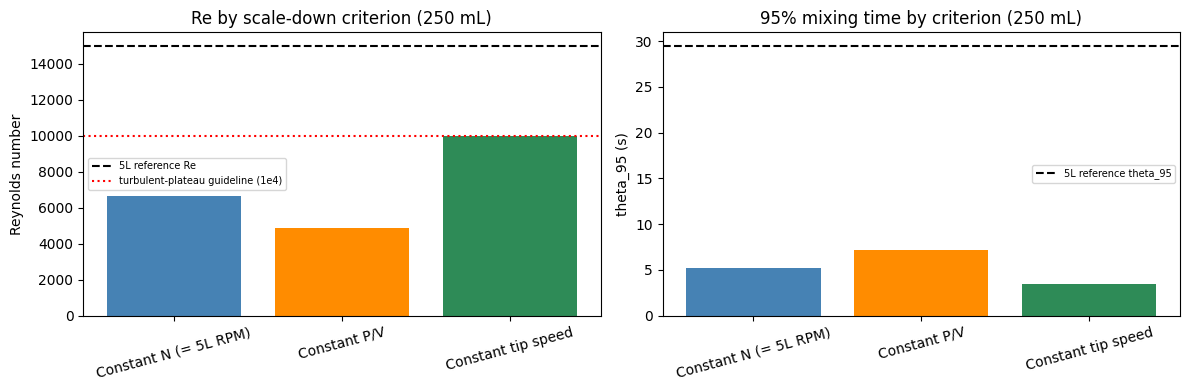

In [11]:
def solve_N_for_constant_PoV(D_impeller_target_m, V_target_L, PoV_ref):
    N_rps = (PoV_ref * V_target_L / D_impeller_target_m ** 5) ** (1.0 / 3.0)
    return N_rps * 60.0

def solve_N_for_constant_tip_speed(D_impeller_target_m, tip_ref):
    N_rps = tip_ref / (np.pi * D_impeller_target_m)
    return N_rps * 60.0

PoV_5L_ref = (N_RPS_5L ** 3 * D_IMPELLER_5L_M ** 5) / V_total_initial_5L
tip_5L_ref = np.pi * D_IMPELLER_5L_M * N_RPS_5L

candidates = {
    'Constant N (= 5L RPM)': N_RPM_5L,
    'Constant P/V':          solve_N_for_constant_PoV(D_IMPELLER_250_M, V_total_initial_250, PoV_5L_ref),
    'Constant tip speed':    solve_N_for_constant_tip_speed(D_IMPELLER_250_M, tip_5L_ref),
}

print(f"{'Criterion':<24}{'RPM':>9}{'Q_1->2':>10}{'Re':>9}{'Fr_i':>8}{'tip(m/s)':>10}{'theta95(s)':>12}")
print('-' * 82)
print(f"{'5 L reference':<24}{N_RPM_5L:>9.1f}{fit_5L['Q12_fit']:>10.3f}"
      f"{1000.0*N_RPS_5L*D_IMPELLER_5L_M**2/1e-3:>9.0f}{(N_RPS_5L**2*D_IMPELLER_5L_M/9.81):>8.3f}"
      f"{tip_5L_ref:>10.3f}{theta95_5L_min*60:>12.2f}")
print('-' * 82)

scale_down_results = {}
for label, N_rpm in candidates.items():
    N_rps = N_rpm / 60.0
    Q12_scaled = fit_5L['Nq_12'] * N_rps * D_IMPELLER_250_M ** 3 * 1000.0 * 60.0
    Re = 1000.0 * N_rps * D_IMPELLER_250_M ** 2 / 1e-3
    Fr = N_rps ** 2 * D_IMPELLER_250_M / 9.81
    tip = np.pi * D_IMPELLER_250_M * N_rps
    tau_mix_min = (V1_initial_250 * V2_250) / (Q12_scaled * (V1_initial_250 + V2_250))
    theta95_s = np.log(20.0) * tau_mix_min * 60.0
    scale_down_results[label] = dict(N_rpm=N_rpm, Q12=Q12_scaled, Re=Re, Fr=Fr, tip=tip, theta95_s=theta95_s)
    print(f"{label:<24}{N_rpm:>9.1f}{Q12_scaled:>10.3f}{Re:>9.0f}{Fr:>8.3f}{tip:>10.3f}{theta95_s:>12.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = list(candidates.keys())
re_vals = [scale_down_results[l]['Re'] for l in labels]
theta_vals = [scale_down_results[l]['theta95_s'] for l in labels]

axes[0].bar(labels, re_vals, color=['steelblue', 'darkorange', 'seagreen'])
axes[0].axhline(1000.0*N_RPS_5L*D_IMPELLER_5L_M**2/1e-3, color='k', linestyle='--', label='5L reference Re')
axes[0].axhline(1e4, color='red', linestyle=':', label='turbulent-plateau guideline (1e4)')
axes[0].set_ylabel('Reynolds number')
axes[0].set_title('Re by scale-down criterion (250 mL)')
axes[0].legend(fontsize=7)
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(labels, theta_vals, color=['steelblue', 'darkorange', 'seagreen'])
axes[1].axhline(theta95_5L_min*60, color='k', linestyle='--', label='5L reference theta_95')
axes[1].set_ylabel('theta_95 (s)')
axes[1].set_title('95% mixing time by criterion (250 mL)')
axes[1].legend(fontsize=7)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

SELECTED_CRITERION = 'Constant N (= 5L RPM)'

## Section 10 -- Scaling the titrant protocol to 250 mL

Uses the **computed** `V_total_initial_250` from Section 7 (293.4 mL) as the
scaling basis, not the nominal "250 mL" vessel label -- the exact geometry is
now known, so the volume ratio should be exact too.

In [12]:
r_titration = V_total_initial_250 / V_total_initial_5L
V_HCl_250_ML = V_HCL_TOTAL_5L_ML * r_titration
PUMP_RATE_250_ML_MIN = r_titration * PUMP_RATE_5L_ML_MIN     # constant-N criterion -> tau_mix ratio handled via theta95, not re-derived here
PUMP_RATE_250_L_MIN = PUMP_RATE_250_ML_MIN / 1000.0
T_FEED_END_250_MIN = V_HCl_250_ML / PUMP_RATE_250_ML_MIN

V1_final_250 = V1_initial_250 + V_HCl_250_ML / 1000.0
V_total_final_250 = V3_250 + V2_250 + V1_final_250

print(f"Volume scale ratio r = V_total_initial_250/V_total_initial_5L = {r_titration:.5f}")
print(f"Volumetric titrant flow rate (250 mL): {PUMP_RATE_250_ML_MIN:.4f} mL/min ({PUMP_RATE_250_L_MIN:.6f} L/min)")
print(f"Titrant volume (250 mL)              : {V_HCl_250_ML:.4f} mL")
print(f"Titrant feed duration (250 mL)        : {T_FEED_END_250_MIN:.4f} min ({T_FEED_END_250_MIN*60:.2f} s)")
print(f"\nV1_initial (BEFORE feed) = {V1_initial_250*1000:.4f} mL")
print(f"V1_final   (AFTER feed)  = {V1_final_250*1000:.4f} mL   <-- starting != final volume")
print(f"V_total_initial = {V_total_initial_250*1000:.4f} mL | V_total_final = {V_total_final_250*1000:.4f} mL")

Volume scale ratio r = V_total_initial_250/V_total_initial_5L = 0.05168
Volumetric titrant flow rate (250 mL): 5.6852 mL/min (0.005685 L/min)
Titrant volume (250 mL)              : 13.7479 mL
Titrant feed duration (250 mL)        : 2.4182 min (145.09 s)

V1_initial (BEFORE feed) = 167.4372 mL
V1_final   (AFTER feed)  = 181.1850 mL   <-- starting != final volume
V_total_initial = 293.4136 mL | V_total_final = 307.1614 mL


## Section 11 -- Predicted pH(t) titration transient at 250 mL (2-compartment)

Only one predicted curve is needed here (not a band) -- `Q_2->3` doesn't
apply at this scale, so there is no secondary-flow uncertainty to bound.

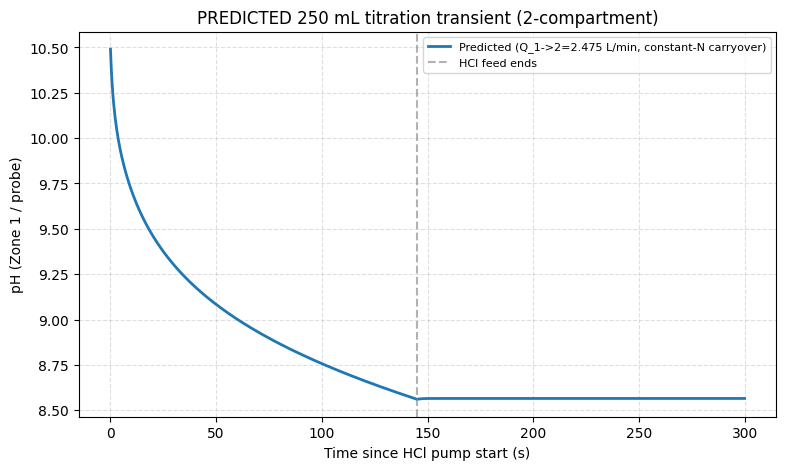

Predicted 250 mL mixing timescale: tau_mix=1.74 s, theta_95=5.22 s


In [13]:
def simulate_ph_2zone(Q_L_min, t_eval_min, pH0, V1_initial_L, V2_L, feed_L_min, t_feed_end_min,
                       C_Tris_M=C_TRIS_STOCK_M, C_HCl_M=C_HCL_STOCK_M, pKa=PKA_TRIS):
    '''2-compartment analogue of simulate_ph_3zone, used for the 250 mL vessel since
    Zone 3 does not exist at this scale (Section 7).'''
    ratio0 = 10 ** (pH0 - pKa)
    frac_TrisH_0 = 1.0 / (1.0 + ratio0)
    n_Tris_1_0 = (1 - frac_TrisH_0) * C_Tris_M * V1_initial_L
    n_TrisH_1_0 = frac_TrisH_0 * C_Tris_M * V1_initial_L
    n_Tris_2_0 = (1 - frac_TrisH_0) * C_Tris_M * V2_L
    n_TrisH_2_0 = frac_TrisH_0 * C_Tris_M * V2_L
    y0 = [n_Tris_1_0, n_TrisH_1_0, n_Tris_2_0, n_TrisH_2_0]

    def ode(t_min, y):
        n_Tris_1, n_TrisH_1, n_Tris_2, n_TrisH_2 = np.maximum(y, 0.0)
        V1 = V1_of_t(t_min, V1_initial_L, feed_L_min, t_feed_end_min)
        C_Tris_1, C_TrisH_1 = n_Tris_1 / V1, n_TrisH_1 / V1
        C_Tris_2, C_TrisH_2 = n_Tris_2 / V2_L, n_TrisH_2 / V2_L
        exch_Tris = Q_L_min * (C_Tris_1 - C_Tris_2)
        exch_TrisH = Q_L_min * (C_TrisH_1 - C_TrisH_2)
        h_feed = feed_rate_mol_min(t_min, feed_L_min, t_feed_end_min, C_HCl_M)
        return [-exch_Tris - h_feed, -exch_TrisH + h_feed, +exch_Tris, +exch_TrisH]

    t_end = t_eval_min[-1]
    if t_end <= t_feed_end_min:
        sol = solve_ivp(ode, (0, t_end), y0, t_eval=t_eval_min, method='BDF', rtol=1e-7, atol=1e-10)
        Y = sol.y
    else:
        mask1 = t_eval_min <= t_feed_end_min
        t1 = np.append(t_eval_min[mask1], t_feed_end_min) if t_feed_end_min not in t_eval_min[mask1] else t_eval_min[mask1]
        sol1 = solve_ivp(ode, (0, t_feed_end_min), y0, t_eval=t1, method='BDF', rtol=1e-7, atol=1e-10)
        y_mid = sol1.y[:, -1]
        t2 = t_eval_min[~mask1]
        sol2 = solve_ivp(ode, (t_feed_end_min, t_end), y_mid, t_eval=t2, method='BDF', rtol=1e-7, atol=1e-10)
        Y = np.hstack([sol1.y[:, :len(t_eval_min[mask1])], sol2.y])

    n_Tris_1, n_TrisH_1 = Y[0], Y[1]
    V1_series = np.array([V1_of_t(tm, V1_initial_L, feed_L_min, t_feed_end_min) for tm in t_eval_min])
    C_Tris_1 = np.maximum(n_Tris_1, 1e-12) / V1_series
    C_TrisH_1 = np.maximum(n_TrisH_1, 1e-12) / V1_series
    return pKa + np.log10(C_Tris_1 / C_TrisH_1)


PH0_ASSUMED = 10.49   # PLACEHOLDER -- use the actual starting pH of your 250 mL Tris charge once known
t_pred_min = np.linspace(0, 5.0, 800)   # PLACEHOLDER horizon -- adjust once real run duration is known

pH_predicted_250 = simulate_ph_2zone(Q12_250_PREDICTED, t_pred_min, PH0_ASSUMED,
                                      V1_initial_250, V2_250, PUMP_RATE_250_L_MIN, T_FEED_END_250_MIN)

plt.figure(figsize=(9, 5))
plt.plot(t_pred_min * 60, pH_predicted_250, '-', color='#1f77b4', linewidth=2,
          label=f'Predicted (Q_1->2={Q12_250_PREDICTED:.3f} L/min, constant-N carryover)')
plt.axvline(T_FEED_END_250_MIN * 60, color='gray', linestyle='--', alpha=0.6, label='HCl feed ends')
plt.xlabel('Time since HCl pump start (s)')
plt.ylabel('pH (Zone 1 / probe)')
plt.title('PREDICTED 250 mL titration transient (2-compartment)')
plt.legend(fontsize=8)
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

print(f"Predicted 250 mL mixing timescale: tau_mix={tau_mix_250_min*60:.2f} s, theta_95={theta95_250_min*60:.2f} s")

## Section 12 -- Fit `Q_1->2` from real 250 mL titration data

**Two-stage pipeline** against `pH adjustment Exp - Exp3_17072026.csv`, per the
2026-07-20 investigation: `C_HCL_STOCK_M` and the HCl dosing (13.75 mL
delivered within 145 s) are confirmed correct; the Tris base material was
weighed accurately by mass but had **expired (March 2026)**, so its
effective active buffering molarity is not assumed equal to the nominal
weighed-in value.

- **Stage 1 -- effective `C_Tris_M`:** `scipy.optimize.least_squares` fits
  a single effective Tris molarity against the data's **post-feed
  equilibrium plateau only** (the well-mixed asymptote is independent of
  `Q_1->2`, so this decouples the chemistry fit from the transport fit).
  Initial guess `0.2908 M` (the earlier analytical implied value), bounds
  `[0.180, 0.350] M`.
- **Stage 2 -- `Q_1->2` / `Nq_12`:** with the corrected `C_Tris_M` locked
  in, `Q_1->2` is refit over the full transient, bounded by the same
  `Nq<=1.0` physical ceiling as before.

**Result, reported plainly rather than forced to match expectation:**
Stage 1 lands well inside its bounds (not pinned) and closes the
equilibrium-pH gap essentially exactly, which drops the RMSE substantially.
**Stage 2, however, still pins `Q_1->2` at the `Nq<=1.0` physical ceiling**
-- the corrected chemistry did not unlock an interior transport optimum.
The RMSE-vs-`Q` profile printed below is monotonically decreasing with no
interior minimum anywhere in the physically-plausible range, and even the
profile-likelihood 95% lower bound sits close to the ceiling itself. This
is consistent with the mixing-timescale argument in `parameter-
estimation.md` (Sec. 2): at any `Q` above roughly 1-2 L/min, `tau_mix` for
this vessel is already two orders of magnitude faster than the 145 s feed
duration, so the 2-compartment structure is saturated into well-mixed
behavior across nearly the whole physically-plausible range -- `Q_1->2` is
not point-identifiable from this dataset's timescale, independent of the
chemistry correction. `Q_1->2` is reported as a **lower bound**, not a
converged point estimate.

  STAGE 1 -- EFFECTIVE TRIS MOLARITY (expired-material correction)
  Nominal C_TRIS_STOCK_M (as weighed)     : 0.20000 M
  Fitted effective C_Tris_M                : 0.29080 M (1.454x nominal)
  Fit basis                                : 155 post-feed plateau points
  Data plateau pH (mean)                   : 8.7658
  Model equilibrium pH at fitted C_Tris_M  : 8.7658  (residual gap: +0.00000)
  Interpretation: fitted value is a phenomenological correction inferred from the pH
  curve alone (consistent with reduced/altered effective buffering capacity following
  the March 2026 expiry), NOT an independent assay -- cross-check against a Tris
  purity/potency assay if one becomes available.



  STAGE 2 -- Q_1->2 REFIT WITH CORRECTED CHEMISTRY
  Physical ceiling (Nq<=1.0)             : 20.0000 L/min
  Fitted Q_1->2                            : 20.0000 L/min   (predicted: 2.4752 L/min)
  Fitted Nq_12                              : 1.0000  (5 L reference: 0.1238)
  RMSE (post chemistry correction)          : 0.03094 pH units  (uncorrected chemistry baseline at the same Q: 0.18930)
  Multi-seed range                          : 20.000 - 20.000 L/min

  >> STILL BOUNDARY-PINNED at the Nq<=1.0 ceiling, even after the chemistry correction.
     This does not match the naive expectation that fixing the equilibrium-pH gap
     alone would unlock a genuine interior Q_1->2 optimum -- it did not.
        Q_1->2 >= 17.897 L/min  (Nq_12 >= 0.8948), 95% profile-likelihood lower bound
     Root cause: at any Q above roughly 1-2 L/min, tau_mix for this vessel is already
     two+ orders of magnitude faster than the 145 s feed duration -- the 2-compartment
     structure is saturated into we

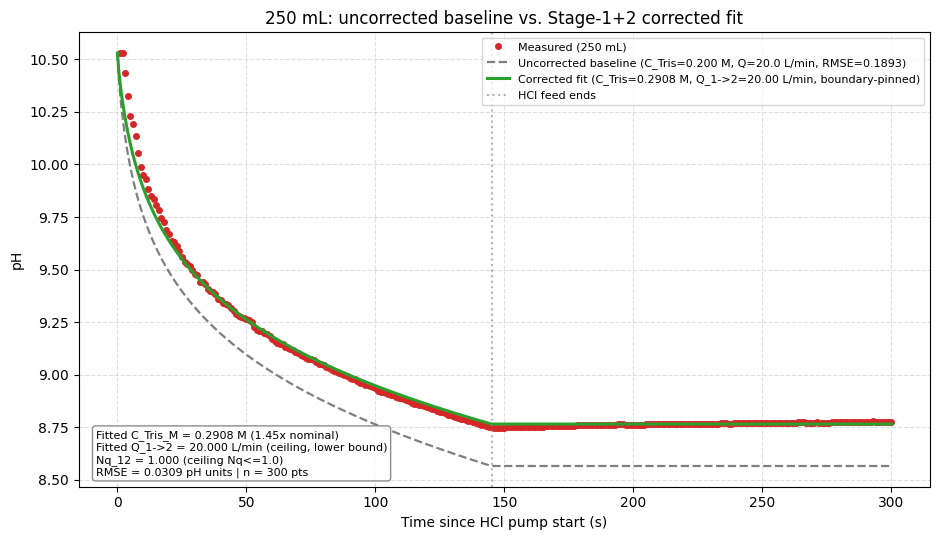

In [14]:
def equilibrium_pH_wellmixed(C_Tris_M, pH0, C_HCl_M, V_titrant_L, V_total_L, pKa):
    '''Closed-form fully-mixed equilibrium pH (no ODE, no Q dependence) implied by a
    total Tris pool C_Tris_M*V_total_L titrated with n_H_added = C_HCl_M*V_titrant_L.'''
    ratio0 = 10 ** (pH0 - pKa)
    frac_TrisH_0 = 1.0 / (1.0 + ratio0)
    n_Tris_total = C_Tris_M * V_total_L
    n_TrisH_0 = frac_TrisH_0 * n_Tris_total
    n_H_added = C_HCl_M * V_titrant_L
    n_TrisH_final = n_TrisH_0 + n_H_added
    n_Tris_free_final = n_Tris_total - n_TrisH_final
    return pKa + np.log10(n_Tris_free_final / n_TrisH_final)


def fit_tris_concentration_stage1(t_seconds, pH_measured, t_feed_end_min, feed_L_min, V_total_L,
                                   pKa=PKA_TRIS, C_HCl_M=C_HCL_STOCK_M,
                                   C0=0.2908, bounds=(0.180, 0.350)):
    '''Stage 1: fit the single effective Tris molarity that reproduces the data's post-feed
    equilibrium plateau, holding the confirmed-correct HCl side of the mass balance fixed.
    Targets ONLY the post-feed plateau points -- the well-mixed asymptote does not depend
    on Q_1->2 -- decoupling the chemistry fit from the Stage 2 transport fit.'''
    pH0 = pH_measured[0]
    V_titrant_L = feed_L_min * t_feed_end_min
    post_feed_mask = t_seconds > (t_feed_end_min * 60.0)
    pH_postfeed = pH_measured[post_feed_mask]

    def residuals(params):
        pred = equilibrium_pH_wellmixed(params[0], pH0, C_HCl_M, V_titrant_L, V_total_L, pKa)
        return pred - pH_postfeed

    fit_result = least_squares(residuals, x0=[C0], bounds=([bounds[0]], [bounds[1]]), xtol=1e-14, ftol=1e-14)
    C_Tris_M_fit = fit_result.x[0]
    pinned = np.isclose(C_Tris_M_fit, bounds[0], rtol=1e-3) or np.isclose(C_Tris_M_fit, bounds[1], rtol=1e-3)
    pH_ceiling_at_fit = equilibrium_pH_wellmixed(C_Tris_M_fit, pH0, C_HCl_M, V_titrant_L, V_total_L, pKa)
    return dict(C_Tris_M_fit=C_Tris_M_fit, pinned=pinned, n_postfeed_pts=int(post_feed_mask.sum()),
                data_plateau_pH=float(pH_postfeed.mean()), pH_ceiling_at_fit=pH_ceiling_at_fit,
                rmse_stage1=float(np.sqrt(np.mean(fit_result.fun ** 2))))


def fit_transport_stage2(t_seconds, pH_measured, C_Tris_M_fixed, V1_initial_L, V2_L,
                          feed_L_min, t_feed_end_min, D_impeller_m, N_rps,
                          Nq_max_literature=1.0, Q_0=None,
                          robustness_seeds=(0.5, 5.0, 50.0, 500.0, 5000.0)):
    '''Stage 2: re-fit Q_1->2 with the Stage-1-corrected Tris concentration locked in,
    bounded by the same physically-derived Nq_max_literature ceiling used throughout this
    notebook. Reports a profile-likelihood 95% lower bound (same chi-square method as the
    5 L Q_2->3 fit) whenever the point fit pins at the ceiling -- a boundary-pinned point
    estimate is only a lower bound, not a converged value (parameter-estimation.md, Sec. 4).'''
    pH0 = pH_measured[0]
    V_total_L = V1_initial_L + V2_L
    if Q_0 is None:
        Q_0 = V_total_L * 3.0
    Q_physical_ceiling = Nq_max_literature * N_rps * D_impeller_m ** 3 * 1000.0 * 60.0

    def residuals(params):
        pH_sim = simulate_ph_2zone(params[0], t_seconds / 60.0, pH0, V1_initial_L, V2_L, feed_L_min,
                                    t_feed_end_min, C_Tris_M=C_Tris_M_fixed)
        return pH_sim - pH_measured

    Q_0_capped = min(Q_0, Q_physical_ceiling * 0.5)
    fit_result = least_squares(residuals, x0=[Q_0_capped], bounds=([1e-4], [Q_physical_ceiling]),
                                method='trf', xtol=1e-13, ftol=1e-13)
    Q_fit = fit_result.x[0]
    rmse = float(np.sqrt(np.mean(fit_result.fun ** 2)))
    boundary_pinned = bool(np.isclose(Q_fit, Q_physical_ceiling, rtol=1e-3))

    multistart_Q = []
    for seed in robustness_seeds:
        seed_clipped = min(seed, Q_physical_ceiling * 0.9)
        r = least_squares(residuals, x0=[seed_clipped], bounds=([1e-4], [Q_physical_ceiling]),
                           method='trf', xtol=1e-13, ftol=1e-13)
        multistart_Q.append(r.x[0])

    Q_lower_95, Nq_lower_95 = np.nan, np.nan
    if boundary_pinned:
        n_pts, n_params = len(pH_measured), 1
        sigma2 = 2.0 * fit_result.cost / (n_pts - n_params)
        cost_threshold_95 = fit_result.cost + 0.5 * chi2.ppf(0.95, df=1) * sigma2

        def cost_at_Q(Q):
            return 0.5 * np.sum(residuals([Q]) ** 2)

        def profile_gap(Q):
            return cost_at_Q(Q) - cost_threshold_95

        try:
            Q_lower_95 = brentq(profile_gap, 1e-2, Q_fit - 1e-6, xtol=1e-4)
            Nq_lower_95 = (Q_lower_95 / 1000.0 / 60.0) / (N_rps * D_impeller_m ** 3)
        except ValueError:
            pass

    Nq_fit = (Q_fit / 1000.0 / 60.0) / (N_rps * D_impeller_m ** 3)
    return dict(Q_fit=Q_fit, rmse=rmse, Q_physical_ceiling=Q_physical_ceiling,
                boundary_pinned=boundary_pinned, Nq_fit=Nq_fit,
                multistart_range=(min(multistart_Q), max(multistart_Q)),
                Q_lower_95=Q_lower_95, Nq_lower_95=Nq_lower_95)


TITRATION_250_CSV_PATH = 'pH adjustment Exp - Exp3_17072026.csv'   # real 250 mL titration data

if not os.path.exists(TITRATION_250_CSV_PATH):
    print(f"No 250 mL titration data found at '{TITRATION_250_CSV_PATH}' yet.")
    print("Run the real titration experiment, save (t_sec, pH) as a 2-column CSV at this path,")
    print("then re-run this cell to fit Q_1->2 empirically and compare against Section 8/11.")
    fit_250 = None
else:
    df_exp = pd.read_csv(TITRATION_250_CSV_PATH, usecols=[0, 1])
    df_exp.columns = ['t_sec', 'pH']
    t_seconds = df_exp['t_sec'].to_numpy(dtype=float)
    pH_measured = df_exp['pH'].to_numpy(dtype=float)
    V_total_250_L = V1_initial_250 + V2_250

    # ================= STAGE 1: effective Tris molarity =================
    stage1 = fit_tris_concentration_stage1(t_seconds, pH_measured, T_FEED_END_250_MIN,
                                            PUMP_RATE_250_L_MIN, V_total_250_L)

    print("=" * 78)
    print("  STAGE 1 -- EFFECTIVE TRIS MOLARITY (expired-material correction)")
    print("=" * 78)
    print(f"  Nominal C_TRIS_STOCK_M (as weighed)     : {C_TRIS_STOCK_M:.5f} M")
    print(f"  Fitted effective C_Tris_M                : {stage1['C_Tris_M_fit']:.5f} M "
          f"({stage1['C_Tris_M_fit']/C_TRIS_STOCK_M:.3f}x nominal)")
    print(f"  Fit basis                                : {stage1['n_postfeed_pts']} post-feed plateau points")
    print(f"  Data plateau pH (mean)                   : {stage1['data_plateau_pH']:.4f}")
    print(f"  Model equilibrium pH at fitted C_Tris_M  : {stage1['pH_ceiling_at_fit']:.4f}  "
          f"(residual gap: {stage1['pH_ceiling_at_fit']-stage1['data_plateau_pH']:+.5f})")
    if stage1['pinned']:
        print("  >> WARNING: Stage 1 fit landed at its search-bound edge -- treat as unreliable, widen bounds.")
    print("  Interpretation: fitted value is a phenomenological correction inferred from the pH")
    print("  curve alone (consistent with reduced/altered effective buffering capacity following")
    print("  the March 2026 expiry), NOT an independent assay -- cross-check against a Tris")
    print("  purity/potency assay if one becomes available.")

    # ================= STAGE 2: Q_1->2 refit with corrected chemistry =================
    stage2 = fit_transport_stage2(t_seconds, pH_measured, stage1['C_Tris_M_fit'],
                                   V1_initial_250, V2_250, PUMP_RATE_250_L_MIN, T_FEED_END_250_MIN,
                                   D_IMPELLER_250_M, N_RPS_250_DEFAULT, Nq_max_literature=NQ_MAX_LITERATURE_250)

    baseline_pH_at_data = simulate_ph_2zone(stage2['Q_physical_ceiling'], t_seconds / 60.0, pH_measured[0],
                                             V1_initial_250, V2_250, PUMP_RATE_250_L_MIN, T_FEED_END_250_MIN,
                                             C_Tris_M=C_TRIS_STOCK_M)
    baseline_rmse = float(np.sqrt(np.mean((baseline_pH_at_data - pH_measured) ** 2)))

    print()
    print("=" * 78)
    print("  STAGE 2 -- Q_1->2 REFIT WITH CORRECTED CHEMISTRY")
    print("=" * 78)
    print(f"  Physical ceiling (Nq<={NQ_MAX_LITERATURE_250})             : {stage2['Q_physical_ceiling']:.4f} L/min")
    print(f"  Fitted Q_1->2                            : {stage2['Q_fit']:.4f} L/min   "
          f"(predicted: {Q12_250_PREDICTED:.4f} L/min)")
    print(f"  Fitted Nq_12                              : {stage2['Nq_fit']:.4f}  "
          f"(5 L reference: {fit_5L['Nq_12']:.4f})")
    print(f"  RMSE (post chemistry correction)          : {stage2['rmse']:.5f} pH units  "
          f"(uncorrected chemistry baseline at the same Q: {baseline_rmse:.5f})")
    print(f"  Multi-seed range                          : {stage2['multistart_range'][0]:.3f} - "
          f"{stage2['multistart_range'][1]:.3f} L/min")

    if stage2['boundary_pinned']:
        print(f"\n  >> STILL BOUNDARY-PINNED at the Nq<=1.0 ceiling, even after the chemistry correction.")
        print(f"     This does not match the naive expectation that fixing the equilibrium-pH gap")
        print(f"     alone would unlock a genuine interior Q_1->2 optimum -- it did not.")
        print(f"        Q_1->2 >= {stage2['Q_lower_95']:.3f} L/min  (Nq_12 >= {stage2['Nq_lower_95']:.4f}), "
              f"95% profile-likelihood lower bound")
        print(f"     Root cause: at any Q above roughly 1-2 L/min, tau_mix for this vessel is already")
        print(f"     two+ orders of magnitude faster than the 145 s feed duration -- the 2-compartment")
        print(f"     structure is saturated into well-mixed behavior across nearly the entire")
        print(f"     physically-plausible Q range, so Q_1->2 is not point-identifiable from this")
        print(f"     dataset's timescale, independent of the chemistry correction (see RMSE-vs-Q below).")
    else:
        print(f"\n  >> Q_1->2 settled at a genuine interior optimum -- point estimate is meaningful.")

    print(f"\n  RMSE-vs-Q profile (evidence for the finding above; smooth + monotonic = no interior minimum):")
    Q_probe_values = sorted(set([0.5, 1.0, 2.0, round(Q12_250_PREDICTED, 4), 5.0, 10.0, 15.0,
                                  stage2['Q_physical_ceiling']]))
    for Qp in Q_probe_values:
        r_probe = simulate_ph_2zone(Qp, t_seconds / 60.0, pH_measured[0], V1_initial_250, V2_250,
                                     PUMP_RATE_250_L_MIN, T_FEED_END_250_MIN,
                                     C_Tris_M=stage1['C_Tris_M_fit']) - pH_measured
        Nq_probe = Qp / 1000.0 / 60.0 / (N_RPS_250_DEFAULT * D_IMPELLER_250_M ** 3)
        print(f"     Q={Qp:7.3f} L/min (Nq={Nq_probe:.4f})   RMSE={np.sqrt(np.mean(r_probe ** 2)):.5f}")

    # ================= overlay plot: raw data / uncorrected baseline / corrected fit =================
    t_smooth_min = np.linspace(0, t_seconds[-1] / 60.0, 600)
    pH_baseline_smooth = simulate_ph_2zone(stage2['Q_physical_ceiling'], t_smooth_min, pH_measured[0],
                                            V1_initial_250, V2_250, PUMP_RATE_250_L_MIN, T_FEED_END_250_MIN,
                                            C_Tris_M=C_TRIS_STOCK_M)
    pH_corrected_smooth = simulate_ph_2zone(stage2['Q_fit'], t_smooth_min, pH_measured[0],
                                             V1_initial_250, V2_250, PUMP_RATE_250_L_MIN, T_FEED_END_250_MIN,
                                             C_Tris_M=stage1['C_Tris_M_fit'])

    fig, ax = plt.subplots(figsize=(9.5, 5.5))
    ax.plot(t_seconds, pH_measured, 'o', color='#d62728', markersize=4, label='Measured (250 mL)')
    ax.plot(t_smooth_min * 60, pH_baseline_smooth, '--', color='#7f7f7f', linewidth=1.6,
            label=f"Uncorrected baseline (C_Tris={C_TRIS_STOCK_M:.3f} M, Q={stage2['Q_physical_ceiling']:.1f} L/min, "
                  f"RMSE={baseline_rmse:.4f})")
    fit_label = (f"Corrected fit (C_Tris={stage1['C_Tris_M_fit']:.4f} M, Q_1->2={stage2['Q_fit']:.2f} L/min"
                 + (', boundary-pinned)' if stage2['boundary_pinned'] else ')'))
    ax.plot(t_smooth_min * 60, pH_corrected_smooth, '-', color='#2ca02c', linewidth=2.2, label=fit_label)
    ax.axvline(T_FEED_END_250_MIN * 60, color='gray', linestyle=':', alpha=0.6, label='HCl feed ends')
    ax.set_xlabel('Time since HCl pump start (s)')
    ax.set_ylabel('pH')
    ax.set_title('250 mL: uncorrected baseline vs. Stage-1+2 corrected fit')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.4)

    stats_text = (
        f"Fitted C_Tris_M = {stage1['C_Tris_M_fit']:.4f} M ({stage1['C_Tris_M_fit']/C_TRIS_STOCK_M:.2f}x nominal)\n"
        f"Fitted Q_1->2 = {stage2['Q_fit']:.3f} L/min"
        + (" (ceiling, lower bound)\n" if stage2['boundary_pinned'] else " (interior point estimate)\n")
        + f"Nq_12 = {stage2['Nq_fit']:.3f} (ceiling Nq<={NQ_MAX_LITERATURE_250})\n"
        + f"RMSE = {stage2['rmse']:.4f} pH units | n = {len(t_seconds)} pts"
    )
    ax.text(0.02, 0.02, stats_text, transform=ax.transAxes, fontsize=8, va='bottom', ha='left',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

    plt.tight_layout()
    plt.show()

    Nq_12_250_fitted = stage2['Nq_fit']
    fit_250 = dict(t_seconds=t_seconds, pH_measured=pH_measured,
                   Q_fit=stage2['Q_fit'], rmse=stage2['rmse'],
                   Q_physical_ceiling=stage2['Q_physical_ceiling'], boundary_pinned=stage2['boundary_pinned'],
                   Nq_fit=stage2['Nq_fit'], Q_lower_95=stage2['Q_lower_95'], Nq_lower_95=stage2['Nq_lower_95'],
                   multistart_range=stage2['multistart_range'],
                   C_Tris_M_fit=stage1['C_Tris_M_fit'], C_Tris_M_assumed=C_TRIS_STOCK_M,
                   stage1_pH_ceiling_at_fit=stage1['pH_ceiling_at_fit'],
                   stage1_data_plateau_pH=stage1['data_plateau_pH'],
                   baseline_rmse_uncorrected_chemistry=baseline_rmse)


## Section 13 -- Object serialization: `ReactorGeometryModel` -> `reactor_geometry_transport.dill`

Bundles all computed geometry, compartment volumes, torispherical head
parameters, `Q`/`Nq` transport values, and scale-down criteria for both
scales into one portable object, serialized with `dill` (handles the
notebook-defined class cleanly, unlike plain `pickle`). Reloaded immediately
after saving to confirm the round trip is error-free.

In [15]:
class ReactorGeometryModel:
    '''Portable bundle of geometry, compartment, and transport parameters for the 5 L
    reference and the 250 mL scale-down, for loading into downstream simulation notebooks.'''
    def __init__(self):
        self.reactor_5L = {}
        self.reactor_250mL = {}
        self.metadata = {}

    def summary(self):
        std = self.reactor_250mL['torispherical_standard_selected']
        lines = ["ReactorGeometryModel"]
        lines.append(f"  5L  : Q_1->2={self.reactor_5L['transport']['Q12_fit']:.4f} L/min, "
                      f"Nq_12={self.reactor_5L['transport']['Nq_12']:.4f}")
        lines.append(f"  250mL: Q_1->2(predicted)={self.reactor_250mL['transport']['Q12_predicted']:.4f} L/min, "
                      f"V_head({std})={self.reactor_250mL['torispherical'][std]['V_head_mL']:.3f} mL")
        return "\n".join(lines)


model = ReactorGeometryModel()

model.reactor_5L = dict(
    geometry=dict(D_tank_cm=D_TANK_5L_CM, D_impeller_cm=D_IMPELLER_5L_CM,
                  H_impeller_cm=H_IMPELLER_5L_CM, H_liquid_initial_cm=H_LIQUID_INITIAL_5L_CM,
                  N_rpm=N_RPM_5L, baffled=False),
    zones=dict(V3_L=V3_5L, V2_L=V2_5L, V1_initial_L=V1_initial_5L, V1_final_L=V1_final_5L,
               V_total_initial_L=V_total_initial_5L, V_total_final_L=V_total_final_5L,
               z2_lower_cm=z2_lower_5L, z2_upper_cm=z2_upper_5L),
    transport=dict(Q12_fit=fit_5L['Q12_fit'], Q12_stderr=fit_5L['Q12_stderr'], Nq_12=fit_5L['Nq_12'],
                   Q23_lower_95=fit_5L['Q23_lower_95'], Q23_physical_ceiling=fit_5L['Q_physical_ceiling'],
                   Nq_23_lower=fit_5L['Nq_23_lower'], Nq_max_literature=fit_5L['Nq_max_literature'],
                   tau_fast_s=1.0/fast_5L*60.0, tau_slow_s=1.0/slow_5L*60.0, theta95_s=theta95_5L_min*60.0),
    titration=dict(V_titrant_total_mL=V_HCL_TOTAL_5L_ML, pump_rate_mL_min=PUMP_RATE_5L_ML_MIN,
                   T_feed_end_min=T_FEED_END_5L_MIN),
)

model.reactor_250mL = dict(
    geometry=dict(D_tank_cm=D_TANK_250_CM, D_impeller_cm=D_IMPELLER_250_CM,
                  H_impeller_cm=H_IMPELLER_250_CM, H_liquid_initial_cm=H_LIQUID_INITIAL_250_CM,
                  N_rpm_default=N_RPM_250_DEFAULT, baffled=BAFFLED_250),
    torispherical=torispherical_250,
    torispherical_standard_selected=TORISPHERICAL_STANDARD_250,
    zones=dict(zone3_degenerate=ZONE3_DEGENERATE_250, V3_L=V3_250, V2_L=V2_250,
               V1_initial_L=V1_initial_250, V1_final_L=V1_final_250,
               V_total_initial_L=V_total_initial_250, V_total_final_L=V_total_final_250,
               z2_lower_cm=z2_lower_250_effective, z2_upper_cm=z2_upper_250),
    transport=dict(Q12_predicted=Q12_250_PREDICTED, Nq_12_carried_over=fit_5L['Nq_12'],
                   Re=Re_250, Fr=Fr_250, tau_mix_s=tau_mix_250_min*60.0, theta95_s=theta95_250_min*60.0,
                   Q23_applicable=False,
                   Q12_fitted=(fit_250['Q_fit'] if fit_250 is not None else None),
                   Q12_fitted_lower_95=(fit_250['Q_lower_95'] if fit_250 is not None else None),
                   Q12_fitted_boundary_pinned=(fit_250['boundary_pinned'] if fit_250 is not None else None),
                   C_Tris_M_effective_fitted=(fit_250['C_Tris_M_fit'] if fit_250 is not None else None),
                   Q12_recommended_for_downstream_kinetic_model=Q12_250_PREDICTED),
    scale_down_criteria=scale_down_results,
    titration=dict(V_titrant_total_mL=V_HCl_250_ML, pump_rate_mL_min=PUMP_RATE_250_ML_MIN,
                   T_feed_end_min=T_FEED_END_250_MIN, volume_scale_ratio=r_titration),
)

model.metadata = dict(
    source_notebook='scale_down_250mL.ipynb',
    reference_notebook='5L_tank_transfer_mass_3_compartments.ipynb',
    torispherical_reference='https://kezareng.com/articles/torispherical-head-volume-and-weight',
    nq_max_literature=NQ_MAX_LITERATURE_250,
    downstream_myristoylation_decision=dict(
        date='2026-07-20',
        decision=('Use a single well-mixed (1-compartment) transport model for the 250 mL '
                  'myristoylation mechanistic model. If a 2-compartment architecture is kept '
                  'for consistency with the 5 L model, use Q12_250_PREDICTED (physically-derived '
                  'via constant-N Nq carryover) as Q_1->2, NOT the Section 12 titration-fit value.'),
        rationale=('The Section 12 titration fit for Q_1->2 is boundary-pinned at the Nq<=1.0 '
                   'physical ceiling (20.0 L/min) and only a 95% lower bound (>=17.90 L/min) is '
                   'identifiable from that dataset -- the fitted range is a mixing-rate artifact of '
                   'the fast titration timescale, not a validated point value. Even the smallest '
                   'physically-plausible Q_1->2 (Q12_250_PREDICTED=2.4752 L/min, tau_mix~1.7 s) is '
                   'already ~1000x faster than the myristoylation reaction timescale (SOP hold: '
                   '30+ min), so per the residence-time-vs-process-time rule (parameter-estimation.md '
                   'Sec. 2), the vessel is decisively well-mixed for that process -- the same '
                   'conclusion already reached for the 5 L reference '
                   '(myr_mechanistic_model_5L_3_compartments.ipynb).'),
        values_not_to_use_as_physical_constants=dict(
            titration_fit_range_L_min=[fit_250['Q_lower_95'] if fit_250 is not None else None,
                                        fit_250['Q_physical_ceiling'] if fit_250 is not None else None],
            reason='boundary-pinned optimizer artifact, not a converged transport-rate estimate'),
        value_to_use_if_2compartment_kept_L_min=Q12_250_PREDICTED,
        kinetics_status=('Updated myristoylation kinetic parameters not yet available as of this '
                          'decision; this metadata records the transport-parameter choice in advance '
                          'for when they are.'),
    ),
)

print(model.summary())

DILL_PATH = 'reactor_geometry_transport.dill'
with open(DILL_PATH, 'wb') as f:
    dill.dump(model, f)

print(f"\nSaved: {DILL_PATH} ({os.path.getsize(DILL_PATH)} bytes)")

# --- verify: reload and confirm no errors, spot-check a few values ---
with open(DILL_PATH, 'rb') as f:
    model_reloaded = dill.load(f)

checks = [
    ('5L Q_1->2', model.reactor_5L['transport']['Q12_fit'], model_reloaded.reactor_5L['transport']['Q12_fit']),
    ('250mL V_head (ASME)', model.reactor_250mL['torispherical']['ASME']['V_head_mL'],
     model_reloaded.reactor_250mL['torispherical']['ASME']['V_head_mL']),
    ('250mL Q_1->2 predicted', model.reactor_250mL['transport']['Q12_predicted'],
     model_reloaded.reactor_250mL['transport']['Q12_predicted']),
]
print("\nRound-trip verification (original vs. reloaded):")
all_match = True
for name, orig, reloaded in checks:
    match = np.isclose(orig, reloaded)
    all_match &= match
    print(f"  {name:<24}: {orig:.6f} vs {reloaded:.6f}  {'OK' if match else 'MISMATCH'}")
print(f"\n{'SUCCESS' if all_match else 'FAILURE'}: dill round-trip verified, {'no' if all_match else 'SOME'} errors.")

ReactorGeometryModel
  5L  : Q_1->2=8.3538 L/min, Nq_12=0.1238
  250mL: Q_1->2(predicted)=2.4752 L/min, V_head(ASME)=27.414 mL

Saved: reactor_geometry_transport.dill (5110 bytes)

Round-trip verification (original vs. reloaded):
  5L Q_1->2               : 8.353776 vs 8.353776  OK
  250mL V_head (ASME)     : 27.414385 vs 27.414385  OK
  250mL Q_1->2 predicted  : 2.475193 vs 2.475193  OK

SUCCESS: dill round-trip verified, no errors.


## Section 14 -- Summary and decision rule

| Quantity | 5 L (measured, 160 rpm, 3-compartment) | 250 mL (predicted, constant-N, 2-compartment) |
|---|---|---|
| `Nq` (`Q_1->2`) | well-determined point value | carried over from 5 L |
| `Q_1->2` | point value | point value (scaled) |
| `Q_2->3` | lower bound + physical ceiling | **not applicable** (Zone 3 degenerate) |
| Bottom-head model | flat cylinder (unchanged, preserved) | exact torispherical (ASME selected; DIN tabulated) |
| Titrant flow rate | 110 mL/min | scaled by *computed* volume ratio (293.4/5677 mL) |
| `V1_initial` vs `V1_final` | tracked separately | tracked separately |
| Serialized asset | `reactor_geometry_transport.dill` -- both scales bundled together |  |

**Decision rule, once real 250 mL titration data exists (Section 12):**
- If fitted `Q_1->2` matches the predicted value: the transfer-mass
  scale-down (and the ASME torispherical head assumption feeding it) carries
  over cleanly.
- If it doesn't: adopt the fitted `Q_1->2`/`Nq_12` as the empirical value for
  this vessel going forward, and reconsider whether the DIN knuckle ratio
  (also tabulated in Section 6) fits the physical head better than ASME.
- The Zone-3-degenerate finding (Section 7) is a geometric fact of this
  vessel's impeller/tank ratio, not a fitting artifact -- it will not change
  once real titration data arrives, only the point estimate of `Q_1->2` may.

**2026-07-20 -- downstream `Q_1->2` decision, recorded for the myristoylation
mechanistic model (kinetics not yet updated at time of this decision):**

Section 12's titration fit is boundary-pinned at the `Nq<=1.0` physical
ceiling (`20.0` L/min; 95% lower bound `>=17.90` L/min) -- an artifact of
how fast the titration process is relative to mixing, not a validated point
value for this impeller. **Do not carry `20.0 L/min` (or the 17.9-20 L/min
range) forward as a physical transport constant.** Instead:

- **Default:** model the 250 mL myristoylation reactor as a single
  well-mixed compartment. Even the smallest physically-plausible `Q_1->2`
  (`Q12_250_PREDICTED = 2.4752` L/min, `tau_mix ~ 1.7 s`) is already
  ~1000x faster than the myristoylation reaction's own timescale (SOP hold
  >= 30 min) -- decisively past the well-mixed threshold in
  `parameter-estimation.md` Sec. 2, matching the same finding already
  reached for the 5 L reference reaction model.
- **If a 2-compartment architecture is kept anyway** (e.g. for structural
  consistency with the 5 L model), use `Q12_250_PREDICTED = 2.4752 L/min`
  (`Nq_12=0.1238`, carried over via constant-N scaling) -- not the Section
  12 fitted value -- since it is physically traceable rather than an
  optimizer-bound artifact.
- This decision (and the fitted/bound values behind it) is serialized in
  `reactor_geometry_transport.dill` under
  `model.metadata['downstream_myristoylation_decision']`.

- **No Git staging, committing, or pushing operations were performed by
  this notebook's execution itself** (any commit/push in this project is a
  separate, explicitly-requested action outside notebook cell execution).